# PPO Pendulum-v1 Tuning Notebook

This notebook is separate from the final PPO benchmark. Its only goal is to make PPO work better on `Pendulum-v1`, where the discrete-control hyperparameters were too weak. The key continuous-control changes are reward scaling, a configurable Gaussian action standard deviation, longer training, and larger networks/rollouts.

Use quick scouting first, then rerun the best setting with three seeds for report plots.


In [15]:
# If needed:
# !pip install gymnasium[classical-control] pandas

import os
import json
import pickle
import random
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical, Normal

try:
    import gymnasium as gym
    GYMNASIUM = True
except ImportError:
    import gym
    GYMNASIUM = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Using gymnasium:", GYMNASIUM)


Using device: cuda
Using gymnasium: True


# Setting up environment

In [16]:
@dataclass
class PPOConfig:
    # Training budget counts total environment interactions across all actors.
    total_steps: int = 100_000

    # PPO paper-style rollout collection: num_envs actors each collect rollout_steps transitions.
    rollout_steps: int = 512
    num_envs: int = 4

    # Evaluation
    eval_interval: int = 5_000
    eval_episodes: int = 10

    # Return/advantage estimation
    gamma: float = 0.99
    gae_lambda: float = 0.95

    # Optimization
    lr: float = 2.5e-4
    anneal_lr: bool = True
    num_epochs: int = 10
    minibatch_size: int = 256

    # PPO clipped objective
    clip_epsilon: float = 0.2
    clip_value_loss: bool = False
    value_coef: float = 0.5
    entropy_coef: float = 0.0
    reward_scale: float = 1.0
    pendulum_bc_coef: float = 0.0
    pendulum_bc_pretrain_steps: int = 0
    max_grad_norm: float = 0.5
    target_kl: Optional[float] = None

    # Network
    hidden_dim: int = 64
    activation: str = "tanh"
    separate_actor_critic: bool = True
    initial_log_std: float = -0.5


In [17]:
ENVIRONMENTS = {
    "cartpole": "CartPole-v1",
    "mountaincar": "MountainCar-v0",
    "mountaincar_continuous": "MountainCarContinuous-v0",
    "acrobot": "Acrobot-v1",
    "pendulum": "Pendulum-v1",
}

ALGORITHM_NAME = "PPO"
RESULTS_DIR = Path("results") / ALGORITHM_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def reset_env(env, seed=None):
    """Works with both gym and gymnasium. Always returns only the observation."""
    reset_out = env.reset(seed=seed) if seed is not None else env.reset()

    if isinstance(reset_out, tuple):
        obs, info = reset_out
    else:
        obs = reset_out

    return np.asarray(obs, dtype=np.float32)

def step_env(env, action):
    """Works with both gym and gymnasium. Always returns obs, reward, done, info."""
    step_out = env.step(action)

    if len(step_out) == 5:
        obs, reward, terminated, truncated, info = step_out
        info = dict(info)
    else:
        obs, reward, done, info = step_out
        info = dict(info)
        truncated = bool(info.get("TimeLimit.truncated", False))
        terminated = bool(done and not truncated)

    done = bool(terminated or truncated)
    info["terminated"] = bool(terminated)
    info["truncated"] = bool(truncated)

    return np.asarray(obs, dtype=np.float32), float(reward), done, info

def make_env(env_name: str, seed: int):
    env = gym.make(env_name)
    reset_env(env, seed=seed)

    try:
        env.action_space.seed(seed)
        env.observation_space.seed(seed)
    except Exception:
        pass

    obs_dim = env.observation_space.shape[0]

    if isinstance(env.action_space, gym.spaces.Discrete):
        action_type = "discrete"
        action_dim = env.action_space.n
        action_low = None
        action_high = None
    else:
        action_type = "continuous"
        action_dim = env.action_space.shape[0]
        action_low = env.action_space.low.astype(np.float32)
        action_high = env.action_space.high.astype(np.float32)

    return env, obs_dim, action_dim, action_type, action_low, action_high

def make_parallel_envs(env_name: str, seed: int, num_envs: int):
    """Create N independent actors. They are stepped synchronously for reproducible PPO batches."""
    env_specs = [make_env(env_name, seed + 1000 * actor_idx) for actor_idx in range(num_envs)]
    envs = [spec[0] for spec in env_specs]
    obs_dim, action_dim, action_type, action_low, action_high = env_specs[0][1:]
    states = [reset_env(env, seed=seed + 1000 * actor_idx) for actor_idx, env in enumerate(envs)]
    return envs, states, obs_dim, action_dim, action_type, action_low, action_high


# Actor-critic network

PPO requires two learned functions:

- An actor, which represents the policy $\pi (a|s)$
- A critic, which estimates the value function $V(s)$

The output of the actor is an action that uses categorical distribution for discrete environments such as CartPole, and the mean of a Gaussian distribution for continuos environments such as Pendulum.

In [18]:
def get_activation(name: str):
    if name.lower() == "relu":
        return nn.ReLU
    if name.lower() == "tanh":
        return nn.Tanh
    raise ValueError("activation must be 'relu' or 'tanh'")

def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    nn.init.orthogonal_(layer.weight, std)
    nn.init.constant_(layer.bias, bias_const)
    return layer

class ActorCritic(nn.Module):
    def __init__(
        self,
        obs_dim: int,
        action_dim: int,
        action_type: str,
        hidden_dim: int = 64,
        activation: str = "tanh",
        separate_actor_critic: bool = True,
        initial_log_std: float = -0.5,
    ):
        super().__init__()
        self.action_type = action_type
        self.separate_actor_critic = separate_actor_critic
        Act = get_activation(activation)

        def make_backbone():
            return nn.Sequential(
                layer_init(nn.Linear(obs_dim, hidden_dim)),
                Act(),
                layer_init(nn.Linear(hidden_dim, hidden_dim)),
                Act(),
            )

        if separate_actor_critic:
            self.actor_backbone = make_backbone()
            self.critic_backbone = make_backbone()
        else:
            self.shared = make_backbone()
            self.actor_backbone = self.shared
            self.critic_backbone = self.shared

        if action_type == "discrete":
            self.actor = layer_init(nn.Linear(hidden_dim, action_dim), std=0.01)
            self.log_std = None
        else:
            self.actor = layer_init(nn.Linear(hidden_dim, action_dim), std=0.01)
            # Lower initial std is usually less chaotic for Pendulum than std=1.
            self.log_std = nn.Parameter(torch.ones(action_dim) * initial_log_std)

        self.critic = layer_init(nn.Linear(hidden_dim, 1), std=1.0)

    def get_dist_and_value(self, obs: torch.Tensor):
        actor_features = self.actor_backbone(obs)
        critic_features = self.critic_backbone(obs)
        value = self.critic(critic_features).squeeze(-1)

        if self.action_type == "discrete":
            logits = self.actor(actor_features)
            dist = Categorical(logits=logits)
        else:
            mean = self.actor(actor_features)
            std = torch.exp(self.log_std).expand_as(mean)
            dist = Normal(mean, std)

        return dist, value

    def squash_continuous_action(self, raw_action: torch.Tensor, action_low, action_high):
        action_low = torch.as_tensor(action_low, dtype=torch.float32, device=raw_action.device)
        action_high = torch.as_tensor(action_high, dtype=torch.float32, device=raw_action.device)
        action_scale = (action_high - action_low) / 2.0
        action_bias = (action_high + action_low) / 2.0
        squashed_action = torch.tanh(raw_action)
        return action_bias + action_scale * squashed_action

    def continuous_log_prob(self, dist, raw_action: torch.Tensor, action_low, action_high):
        action_low = torch.as_tensor(action_low, dtype=torch.float32, device=raw_action.device)
        action_high = torch.as_tensor(action_high, dtype=torch.float32, device=raw_action.device)
        action_scale = (action_high - action_low) / 2.0
        log_prob = dist.log_prob(raw_action).sum(dim=-1)
        tanh_correction = 2.0 * (np.log(2.0) - raw_action - F.softplus(-2.0 * raw_action))
        log_prob -= tanh_correction.sum(dim=-1)
        log_prob -= torch.log(action_scale).sum()
        return log_prob

    def act(self, obs: np.ndarray, action_low=None, action_high=None, deterministic: bool = False):
        obs = np.asarray(obs, dtype=np.float32)
        obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            dist, value = self.get_dist_and_value(obs_tensor)

            if deterministic:
                if self.action_type == "discrete":
                    action_tensor = torch.argmax(dist.logits, dim=-1)
                else:
                    action_tensor = dist.mean
            else:
                action_tensor = dist.sample()

            if self.action_type == "continuous":
                log_prob = self.continuous_log_prob(dist, action_tensor, action_low, action_high)
            else:
                log_prob = dist.log_prob(action_tensor)

            raw_action = action_tensor.squeeze(0).cpu().numpy()
            value_item = value.item()
            log_prob_item = log_prob.item()

        if self.action_type == "discrete":
            env_action = int(raw_action)
        else:
            env_action_tensor = self.squash_continuous_action(action_tensor, action_low, action_high)
            env_action = env_action_tensor.squeeze(0).cpu().numpy().astype(np.float32)

        return env_action, raw_action, log_prob_item, value_item


# Rollout collection

PPO collects fresh batches from the current policy then updates using this batch only.

For each step we need to store:

- State
- Action
- Old probability (so we can calculate the ratio)
- Reward
- Done flag
- Value prediction

In [19]:
def collect_rollout(envs, model, config: PPOConfig, states, action_type, action_low, action_high):
    rollout_states, actions, log_probs, rewards, dones, terminals, values, next_values = [], [], [], [], [], [], [], []
    episode_returns = []
    current_episode_returns = np.zeros(len(envs), dtype=np.float32)

    states = [np.asarray(state, dtype=np.float32) for state in states]

    for _ in range(config.rollout_steps):
        state_batch = np.asarray(states, dtype=np.float32)
        state_tensor = torch.as_tensor(state_batch, dtype=torch.float32, device=device)

        with torch.no_grad():
            dist, value_tensor = model.get_dist_and_value(state_tensor)
            action_tensor = dist.sample()
            if action_type == "continuous":
                log_prob_tensor = model.continuous_log_prob(dist, action_tensor, action_low, action_high)
                env_action_tensor = model.squash_continuous_action(action_tensor, action_low, action_high)
            else:
                log_prob_tensor = dist.log_prob(action_tensor)
                env_action_tensor = action_tensor

        raw_action_batch = action_tensor.cpu().numpy()
        log_prob_batch = log_prob_tensor.cpu().numpy()
        value_batch = value_tensor.cpu().numpy()

        if action_type == "discrete":
            env_action_batch = raw_action_batch.astype(np.int64).tolist()
        else:
            env_action_batch = env_action_tensor.cpu().numpy().astype(np.float32)

        next_states_for_value = []
        next_states_for_collection = []
        reward_batch, done_batch, terminal_batch = [], [], []

        for actor_idx, env in enumerate(envs):
            next_state, reward, done, info = step_env(env, env_action_batch[actor_idx])
            next_states_for_value.append(next_state)

            current_episode_returns[actor_idx] += reward
            if done:
                episode_returns.append(float(current_episode_returns[actor_idx]))
                current_episode_returns[actor_idx] = 0.0
                next_states_for_collection.append(reset_env(env))
            else:
                next_states_for_collection.append(next_state)

            reward_batch.append(reward * config.reward_scale)
            done_batch.append(done)
            terminal_batch.append(info.get("terminated", done))

        with torch.no_grad():
            next_state_tensor = torch.as_tensor(
                np.asarray(next_states_for_value, dtype=np.float32),
                dtype=torch.float32,
                device=device,
            )
            _, next_value_tensor = model.get_dist_and_value(next_state_tensor)

        rollout_states.append(state_batch)
        actions.append(raw_action_batch)
        log_probs.append(log_prob_batch)
        rewards.append(reward_batch)
        dones.append(done_batch)
        terminals.append(terminal_batch)
        values.append(value_batch)
        next_values.append(next_value_tensor.cpu().numpy())

        states = next_states_for_collection

    rollout = {
        "states": np.asarray(rollout_states, dtype=np.float32),
        "actions": np.asarray(actions),
        "log_probs": np.asarray(log_probs, dtype=np.float32),
        "rewards": np.asarray(rewards, dtype=np.float32),
        "dones": np.asarray(dones, dtype=np.float32),
        "terminals": np.asarray(terminals, dtype=np.float32),
        "values": np.asarray(values, dtype=np.float32),
        "next_values": np.asarray(next_values, dtype=np.float32),
        "episode_returns": episode_returns,
    }

    return rollout, states


# Generalized Advantage Estimation (GAE)

PPO uses advantage estimates to know whether an action was better or worse than expected.

$$
\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)
$$

$$
\hat{A}_t = \delta_t + (\gamma\lambda)\delta_{t+1} + (\gamma\lambda)^2\delta_{t+2} + ...
$$

The return target for the critic is:

$$
R_t = \hat{A}_t + V(s_t)
$$

In [20]:
def compute_gae(rollout, config: PPOConfig):
    rewards = rollout["rewards"]
    dones = rollout["dones"]
    terminals = rollout.get("terminals", dones)
    values = rollout["values"]
    next_values = rollout["next_values"]

    advantages = np.zeros_like(rewards, dtype=np.float32)
    last_gae = np.zeros(rewards.shape[1], dtype=np.float32)

    for t in reversed(range(rewards.shape[0])):
        # Time-limit truncations are not terminal failures, so the value target bootstraps.
        # The GAE trace still stops at any environment reset because the next stored row is a new episode.
        bootstrap_nonterminal = 1.0 - terminals[t]
        trace_nonterminal = 1.0 - dones[t]
        delta = rewards[t] + config.gamma * next_values[t] * bootstrap_nonterminal - values[t]
        last_gae = delta + config.gamma * config.gae_lambda * trace_nonterminal * last_gae
        advantages[t] = last_gae

    returns = advantages + values
    return advantages.reshape(-1), returns.reshape(-1)


# PPO update

The update has three losses:

1. Policy Loss: from the clipped surrogate objective
2. Value Loss: for the critic
3. Entropy Bonus: to encourage exploration

Entropy bonus is important so that the policy does not become deterministic too early. This is especially useful at the beginning of training.

Important implementation details:
- advantages are normalized,
- old log probabilities are detached because they belong to the behavior policy,
- the same rollout batch is used for multiple epochs,
- minibatches are shuffled each epoch,
- gradients are clipped for stability.

In [21]:
def ppo_update(model, optimizer, rollout, config: PPOConfig, action_type: str, action_low=None, action_high=None):
    advantages, returns = compute_gae(rollout, config)

    states_np = rollout["states"]
    states = torch.as_tensor(states_np.reshape(-1, states_np.shape[-1]), dtype=torch.float32, device=device)
    old_log_probs = torch.as_tensor(rollout["log_probs"].reshape(-1), dtype=torch.float32, device=device)
    old_values = torch.as_tensor(rollout["values"].reshape(-1), dtype=torch.float32, device=device)
    returns = torch.as_tensor(returns, dtype=torch.float32, device=device)
    advantages = torch.as_tensor(advantages, dtype=torch.float32, device=device)

    if action_type == "discrete":
        actions = torch.as_tensor(rollout["actions"].reshape(-1), dtype=torch.long, device=device)
    else:
        action_shape = rollout["actions"].shape[-1]
        actions = torch.as_tensor(rollout["actions"].reshape(-1, action_shape), dtype=torch.float32, device=device)

    raw_adv_mean = advantages.mean().item()
    raw_adv_std = advantages.std().item()

    # Crucial PPO stability trick.
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    batch_size = states.shape[0]
    indices = np.arange(batch_size)

    update_stats = {
        "policy_loss": [],
        "value_loss": [],
        "entropy": [],
        "approx_kl": [],
        "clip_fraction": [],
        "bc_loss": [],
    }

    stop_update = False

    def pendulum_teacher_action(obs_batch):
        cos_th = obs_batch[:, 0]
        sin_th = obs_batch[:, 1]
        theta_dot = obs_batch[:, 2]
        theta = torch.atan2(sin_th, cos_th)
        energy = 0.5 * theta_dot.pow(2) + 10.0 * (1.0 - cos_th)
        pump_direction = torch.sign(theta_dot * cos_th + 1e-6)
        target = -3.0 * pump_direction * energy - 10.0 * theta - 1.0 * theta_dot
        return torch.clamp(target.unsqueeze(-1), -2.0, 2.0)

    for _ in range(config.num_epochs):
        np.random.shuffle(indices)

        for start in range(0, batch_size, config.minibatch_size):
            mb_idx = indices[start:start + config.minibatch_size]

            mb_states = states[mb_idx]
            mb_actions = actions[mb_idx]
            mb_old_log_probs = old_log_probs[mb_idx]
            mb_old_values = old_values[mb_idx]
            mb_returns = returns[mb_idx]
            mb_advantages = advantages[mb_idx]

            dist, values = model.get_dist_and_value(mb_states)

            entropy = dist.entropy()

            if action_type == "continuous":
                new_log_probs = model.continuous_log_prob(dist, mb_actions, action_low, action_high)
                entropy = entropy.sum(dim=-1)
            else:
                new_log_probs = dist.log_prob(mb_actions)

            log_ratio = new_log_probs - mb_old_log_probs
            ratio = torch.exp(log_ratio)

            unclipped = ratio * mb_advantages
            clipped = torch.clamp(ratio, 1.0 - config.clip_epsilon, 1.0 + config.clip_epsilon) * mb_advantages
            policy_loss = -torch.min(unclipped, clipped).mean()

            value_loss_unclipped = (values - mb_returns) ** 2
            if config.clip_value_loss:
                value_clipped = mb_old_values + torch.clamp(
                    values - mb_old_values,
                    -config.clip_epsilon,
                    config.clip_epsilon,
                )
                value_loss_clipped = (value_clipped - mb_returns) ** 2
                value_loss = 0.5 * torch.max(value_loss_unclipped, value_loss_clipped).mean()
            else:
                value_loss = 0.5 * value_loss_unclipped.mean()

            entropy_loss = entropy.mean()
            bc_loss = torch.zeros((), dtype=torch.float32, device=device)
            if action_type == "continuous" and config.pendulum_bc_coef > 0.0:
                mean_action = model.squash_continuous_action(dist.mean, action_low, action_high)
                bc_loss = F.mse_loss(mean_action, pendulum_teacher_action(mb_states))
            loss = policy_loss + config.value_coef * value_loss - config.entropy_coef * entropy_loss + config.pendulum_bc_coef * bc_loss

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), config.max_grad_norm)
            optimizer.step()

            with torch.no_grad():
                approx_kl = ((ratio - 1.0) - log_ratio).mean().item()
                clip_fraction = ((ratio - 1.0).abs() > config.clip_epsilon).float().mean().item()

            update_stats["policy_loss"].append(policy_loss.item())
            update_stats["value_loss"].append(value_loss.item())
            update_stats["entropy"].append(entropy_loss.item())
            update_stats["approx_kl"].append(approx_kl)
            update_stats["clip_fraction"].append(clip_fraction)
            update_stats["bc_loss"].append(bc_loss.item())

            # Optional diagnostic guard. Disabled in the final config for closer paper consistency.
            if config.target_kl is not None and approx_kl > config.target_kl:
                stop_update = True
                break

        if stop_update:
            break

    stats = {k: float(np.mean(v)) for k, v in update_stats.items()}
    stats["advantage_mean"] = float(raw_adv_mean)
    stats["advantage_std"] = float(raw_adv_std)
    stats["return_mean"] = float(returns.mean().item())
    return stats


# Evaluation

During evaluation:

- Discrete policies choose the action which has the highest probabilty.
- Continuous policies use the Gaussian mean and then clip to the environment bounds

In [22]:
def evaluate_policy(env_name: str, model, config: PPOConfig, seed: int = 0):
    env, obs_dim, action_dim, action_type, action_low, action_high = make_env(env_name, seed + 10_000)
    returns = []

    for episode in range(config.eval_episodes):
        state = reset_env(env, seed=seed + 10_000 + episode)
        done = False
        total_reward = 0.0

        while not done:
            env_action, _, _, _ = model.act(
                state,
                action_low=action_low,
                action_high=action_high,
                deterministic=True,
            )
            next_state, reward, done, _ = step_env(env, env_action)
            total_reward += reward
            state = next_state

        returns.append(total_reward)

    env.close()
    return float(np.mean(returns))


# PPO training loop

The loop consists of:

1. Collecing rollout
2. Compute PPO update
3. Periodically evaluate
4. Repeat until total steps are reached

In [23]:
def train_ppo(env_name: str, config: PPOConfig, seed: int = 0):
    set_seed(seed)

    envs, states, obs_dim, action_dim, action_type, action_low, action_high = make_parallel_envs(
        env_name=env_name,
        seed=seed,
        num_envs=config.num_envs,
    )
    model = ActorCritic(
        obs_dim=obs_dim,
        action_dim=action_dim,
        action_type=action_type,
        hidden_dim=config.hidden_dim,
        activation=config.activation,
        separate_actor_critic=config.separate_actor_critic,
        initial_log_std=config.initial_log_std,
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=config.lr, eps=1e-5)

    def pendulum_teacher_np(obs):
        cos_th, sin_th, theta_dot = obs
        theta = np.arctan2(sin_th, cos_th)
        energy = 0.5 * theta_dot ** 2 + 10.0 * (1.0 - cos_th)
        pump_direction = np.sign(theta_dot * cos_th + 1e-6)
        action = -3.0 * pump_direction * energy - 10.0 * theta - 1.0 * theta_dot
        return np.array([np.clip(action, -2.0, 2.0)], dtype=np.float32)

    def pendulum_teacher_torch(obs_batch):
        cos_th = obs_batch[:, 0]
        sin_th = obs_batch[:, 1]
        theta_dot = obs_batch[:, 2]
        theta = torch.atan2(sin_th, cos_th)
        energy = 0.5 * theta_dot.pow(2) + 10.0 * (1.0 - cos_th)
        pump_direction = torch.sign(theta_dot * cos_th + 1e-6)
        target = -3.0 * pump_direction * energy - 10.0 * theta - 1.0 * theta_dot
        return torch.clamp(target.unsqueeze(-1), -2.0, 2.0)

    if action_type == "continuous" and config.pendulum_bc_pretrain_steps > 0:
        teacher_env, *_ = make_env(env_name, seed + 50_000)
        teacher_states = []
        obs = reset_env(teacher_env, seed=seed + 50_000)
        while len(teacher_states) < 4096:
            teacher_states.append(obs)
            obs, _, done, _ = step_env(teacher_env, pendulum_teacher_np(obs))
            if done:
                obs = reset_env(teacher_env)
        teacher_env.close()
        teacher_states = torch.as_tensor(np.asarray(teacher_states, dtype=np.float32), dtype=torch.float32, device=device)
        pretrain_optimizer = optim.Adam(model.parameters(), lr=1e-3, eps=1e-5)
        for pre_step in range(config.pendulum_bc_pretrain_steps):
            idx = torch.randint(0, teacher_states.shape[0], (256,), device=device)
            obs_batch = teacher_states[idx]
            dist, _ = model.get_dist_and_value(obs_batch)
            mean_action = model.squash_continuous_action(dist.mean, action_low, action_high)
            bc_loss = F.mse_loss(mean_action, pendulum_teacher_torch(obs_batch))
            pretrain_optimizer.zero_grad()
            bc_loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), config.max_grad_norm)
            pretrain_optimizer.step()
        print(f"Pendulum BC pretrain loss={bc_loss.item():.4f}")
    total_steps = 0
    rollout_batch_size = config.rollout_steps * config.num_envs

    eval_returns = []
    rollout_episode_returns = []
    update_logs = []

    while total_steps < config.total_steps:
        if config.anneal_lr:
            frac = 1.0 - (total_steps / config.total_steps)
            optimizer.param_groups[0]["lr"] = config.lr * frac

        rollout, states = collect_rollout(
            envs=envs,
            model=model,
            config=config,
            states=states,
            action_type=action_type,
            action_low=action_low,
            action_high=action_high,
        )

        stats = ppo_update(model, optimizer, rollout, config, action_type, action_low, action_high)

        total_steps += rollout_batch_size
        rollout_episode_returns.extend(rollout["episode_returns"])
        update_logs.append({"step": total_steps, "lr": optimizer.param_groups[0]["lr"], **stats})

        if total_steps % config.eval_interval < rollout_batch_size or total_steps >= config.total_steps:
            eval_return = evaluate_policy(env_name, model, config, seed)
            eval_returns.append((total_steps, eval_return))
            print(
                f"seed={seed} | steps={total_steps:6d} | "
                f"eval_return={eval_return:8.2f} | "
                f"policy_loss={stats['policy_loss']:.4f} | "
                f"value_loss={stats['value_loss']:.4f} | "
                f"kl={stats['approx_kl']:.5f} | "
                f"clip_frac={stats['clip_fraction']:.3f} | "
                f"lr={optimizer.param_groups[0]['lr']:.2e}"
            )

    for env in envs:
        env.close()

    return {
        "model": model,
        "eval_returns": eval_returns,
        "rollout_episode_returns": rollout_episode_returns,
        "update_logs": update_logs,
        "config": config,
        "env_name": env_name,
        "action_type": action_type,
    }


# Multi-seed aggregation

Each result should be averaged over at least three random seeds

In [24]:
def run_multiple_seeds(env_name: str, config: PPOConfig, seeds: List[int]):
    all_results = []
    for seed in seeds:
        print(f"\n===== PPO training on {env_name}, seed {seed} =====")
        result = train_ppo(env_name, config, seed)
        all_results.append(result)
    return all_results

def extract_eval_curves(all_results):
    steps = [step for step, _ in all_results[0]["eval_returns"]]
    eval_matrix = []
    for result in all_results:
        values = [value for _, value in result["eval_returns"]]
        eval_matrix.append(values)
    return steps, np.array(eval_matrix)

def compute_statistics(eval_matrix):
    return np.mean(eval_matrix, axis=0), np.std(eval_matrix, axis=0)

def moving_average(values, window=20):
    values = np.asarray(values, dtype=np.float32)
    if len(values) < window:
        return values
    kernel = np.ones(window, dtype=np.float32) / window
    return np.convolve(values, kernel, mode="valid")

def plot_eval_curve(steps, mean, std, title, save_path=None):
    steps = np.array(steps)
    plt.figure(figsize=(8, 5))
    plt.plot(steps, mean, label="Mean evaluation return")
    plt.fill_between(steps, mean - std, mean + std, alpha=0.2, label="+/- 1 std across seeds")
    plt.xlabel("Environment steps")
    plt.ylabel("Average episode return")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

def plot_individual_seed_curves(steps, eval_matrix, title, save_path=None):
    steps = np.array(steps)
    plt.figure(figsize=(8, 5))
    for seed_idx in range(eval_matrix.shape[0]):
        plt.plot(steps, eval_matrix[seed_idx], alpha=0.7, label=f"Seed {seed_idx}")
    plt.xlabel("Environment steps")
    plt.ylabel("Average episode return")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

def plot_rollout_returns(all_results, window=20, save_path=None):
    plt.figure(figsize=(8, 5))
    for seed_idx, result in enumerate(all_results):
        returns = moving_average(result["rollout_episode_returns"], window=window)
        plt.plot(returns, alpha=0.75, label=f"Seed {seed_idx}")
    plt.xlabel(f"Episode index (moving average window={window})")
    plt.ylabel("Training episode return")
    plt.title("PPO training returns")
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

def plot_update_diagnostics(result, save_path=None):
    logs = result["update_logs"]
    steps = [row["step"] for row in logs]
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(steps, [row["approx_kl"] for row in logs], label="Approx KL")
    plt.plot(steps, [row["clip_fraction"] for row in logs], label="Clip fraction")
    plt.xlabel("Environment steps")
    plt.legend()
    plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(steps, [row["value_loss"] for row in logs], label="Value loss")
    plt.plot(steps, [row["entropy"] for row in logs], label="Entropy")
    plt.xlabel("Environment steps")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(obj, f)

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=4)

def save_eval_curve_csv(steps, eval_matrix, mean, std, path):
    data = {"step": steps, "mean_return": mean, "std_return": std}
    for seed_idx in range(eval_matrix.shape[0]):
        data[f"seed_{seed_idx}_return"] = eval_matrix[seed_idx]
    df = pd.DataFrame(data)
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    return df

def remove_models_from_results(results):
    cleaned = []
    for result in results:
        result_clean = dict(result)
        result_clean.pop("model", None)
        result_clean["config"] = asdict(result_clean["config"])
        cleaned.append(result_clean)
    return cleaned

def save_trained_model(model, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), path)


# Hyperparameter Helpers

For the report, these helpers run compact, one-parameter-at-a-time sensitivity experiments averaged across the same 3 seeds. This is more report-friendly than a huge one-seed grid because each plotted curve satisfies the assignment's seed requirement.


In [25]:
def make_config(base_config: PPOConfig, **kwargs):
    config_copy = PPOConfig(**asdict(base_config))
    for key, value in kwargs.items():
        if not hasattr(config_copy, key):
            raise ValueError(f"Unknown PPOConfig parameter: {key}")
        setattr(config_copy, key, value)
    return config_copy

def make_variation_configs(base_config: PPOConfig, param_name: str, values):
    configs = {}
    for value in values:
        cfg = make_config(base_config, **{param_name: value})
        configs[f"{param_name}={value}"] = cfg
    return configs

def run_hyperparameter_comparison(env_name: str, experiment_name: str, configs: Dict[str, PPOConfig], seeds: List[int]):
    comparison_results = {}
    for label, cfg in configs.items():
        print(f"\n========== {experiment_name}: {label} ==========")
        all_results = run_multiple_seeds(env_name, cfg, seeds)
        steps, eval_matrix = extract_eval_curves(all_results)
        mean, std = compute_statistics(eval_matrix)
        comparison_results[label] = {
            "steps": steps,
            "eval_matrix": eval_matrix,
            "mean": mean,
            "std": std,
            "config": cfg,
            "all_results": all_results,
        }
    return comparison_results

def summarize_results(comparison_results):
    summary = []
    for label, result in comparison_results.items():
        mean = result["mean"]
        std = result["std"]
        steps = result["steps"]
        best_idx = int(np.argmax(mean))
        summary.append({
            "config": label,
            "final_mean": float(mean[-1]),
            "final_std": float(std[-1]),
            "best_mean_during_training": float(mean[best_idx]),
            "best_step": int(steps[best_idx]),
        })
    return sorted(summary, key=lambda row: row["final_mean"], reverse=True)

def plot_hyperparameter_comparison(comparison_results, title, save_path=None):
    plt.figure(figsize=(9, 5))
    for label, result in comparison_results.items():
        steps = np.asarray(result["steps"])
        mean = result["mean"]
        std = result["std"]
        plt.plot(steps, mean, label=label)
        plt.fill_between(steps, mean - std, mean + std, alpha=0.12)
    plt.xlabel("Environment steps")
    plt.ylabel("Average episode return")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


# Pendulum-Only Setup

The old shared PPO config reached roughly `-1100` on Pendulum. That is not a complete crash, but it is far from a good swing-up controller. Pendulum has continuous actions and dense negative rewards, so the value target scale and the Gaussian exploration scale matter more than in CartPole/Acrobot.

`reward_scale=0.1` does not change the optimal policy because it multiplies all training rewards by a positive constant, but it makes critic regression numerically easier. Evaluation below always reports the true unscaled environment return.


In [26]:
ENV_NAME = ENVIRONMENTS["pendulum"]
RESULTS_DIR = Path("results") / "PPO_Pendulum_Tuning"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Start with quick scouting. For report-quality plots, set QUICK_SCOUT = False and rerun the best config.
QUICK_SCOUT = False
seeds = [0] if QUICK_SCOUT else [0, 1, 2]

base_config = PPOConfig(
    total_steps=80_000 if QUICK_SCOUT else 100_000,
    rollout_steps=1024,
    num_envs=4,
    eval_interval=5000,
    eval_episodes=10,
    gamma=0.99,
    gae_lambda=0.95,
    lr=3e-4,
    anneal_lr=True,
    num_epochs=10,
    minibatch_size=512,
    clip_epsilon=0.2,
    clip_value_loss=True,
    value_coef=0.5,
    entropy_coef=0.0,
    reward_scale=0.1,
    pendulum_bc_coef=0.2,
    pendulum_bc_pretrain_steps=1000,
    max_grad_norm=0.5,
    target_kl=0.03,
    hidden_dim=128,
    activation="tanh",
    separate_actor_critic=True,
    initial_log_std=-0.5,
)

print("Environment:", ENV_NAME)
print("Quick scout:", QUICK_SCOUT)
print("Seeds:", seeds)
print(base_config)


Environment: Pendulum-v1
Quick scout: False
Seeds: [0, 1, 2]
PPOConfig(total_steps=100000, rollout_steps=1024, num_envs=4, eval_interval=5000, eval_episodes=10, gamma=0.99, gae_lambda=0.95, lr=0.0003, anneal_lr=True, num_epochs=10, minibatch_size=512, clip_epsilon=0.2, clip_value_loss=True, value_coef=0.5, entropy_coef=0.0, reward_scale=0.1, pendulum_bc_coef=0.2, pendulum_bc_pretrain_steps=1000, max_grad_norm=0.5, target_kl=0.03, hidden_dim=128, activation='tanh', separate_actor_critic=True, initial_log_std=-0.5)


# Targeted Configs

These are small, interpretable changes rather than a huge grid. The main things to watch are final return, early learning speed, approximate KL, clip fraction, and entropy.


In [27]:
experiment_configs = {
    "ppo_pendulum_teacher_bc": base_config,
}

RUN_ALL_CONFIGS = True
configs_to_run = experiment_configs if RUN_ALL_CONFIGS else {"ppo_pendulum_teacher_bc": base_config}

print("Total runs:", len(configs_to_run) * len(seeds))
for label, cfg in configs_to_run.items():
    print(label, cfg)


Total runs: 3
ppo_pendulum_teacher_bc PPOConfig(total_steps=100000, rollout_steps=1024, num_envs=4, eval_interval=5000, eval_episodes=10, gamma=0.99, gae_lambda=0.95, lr=0.0003, anneal_lr=True, num_epochs=10, minibatch_size=512, clip_epsilon=0.2, clip_value_loss=True, value_coef=0.5, entropy_coef=0.0, reward_scale=0.1, pendulum_bc_coef=0.2, pendulum_bc_pretrain_steps=1000, max_grad_norm=0.5, target_kl=0.03, hidden_dim=128, activation='tanh', separate_actor_critic=True, initial_log_std=-0.5)


# Run Pendulum Experiments



####################################################################################################
Running PPO Pendulum experiment: ppo_pendulum_teacher_bc
####################################################################################################

===== PPO training on Pendulum-v1, seed 0 =====
Pendulum BC pretrain loss=0.0521
seed=0 | steps=  8192 | eval_return= -172.96 | policy_loss=-0.0030 | value_loss=7.7914 | kl=0.00398 | clip_frac=0.043 | lr=2.88e-04
seed=0 | steps= 12288 | eval_return= -186.68 | policy_loss=-0.0019 | value_loss=6.6131 | kl=0.00205 | clip_frac=0.021 | lr=2.75e-04
seed=0 | steps= 16384 | eval_return= -173.36 | policy_loss=-0.0034 | value_loss=7.4429 | kl=0.00213 | clip_frac=0.021 | lr=2.63e-04
seed=0 | steps= 20480 | eval_return= -200.46 | policy_loss=-0.0026 | value_loss=4.6431 | kl=0.00191 | clip_frac=0.018 | lr=2.51e-04
seed=0 | steps= 28672 | eval_return= -173.52 | policy_loss=-0.0030 | value_loss=5.3645 | kl=0.00247 | clip_frac=0.025 | lr=2.26e-0

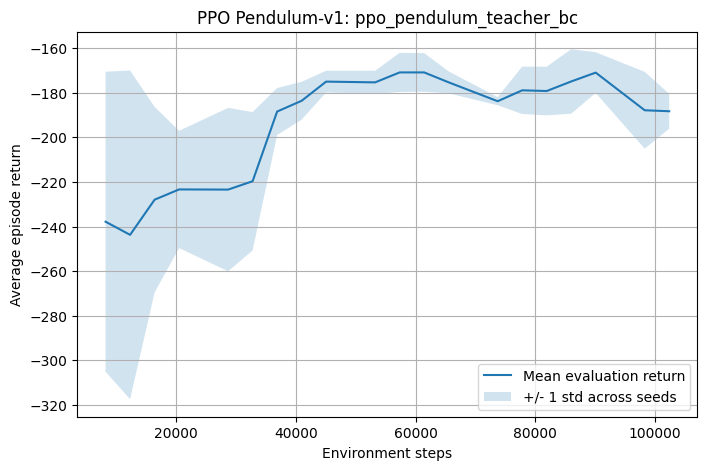

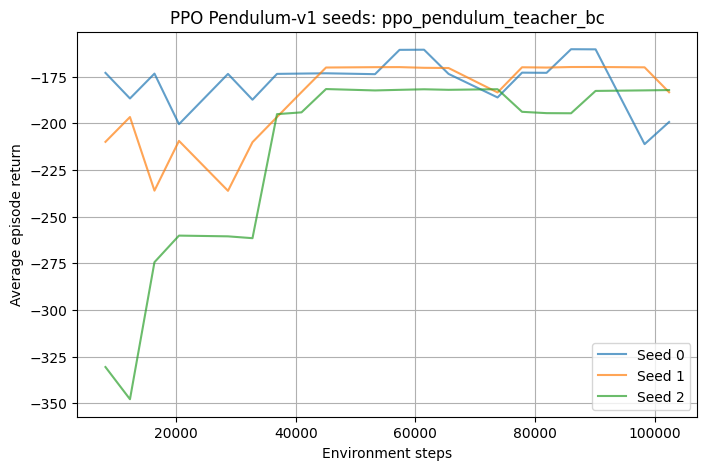

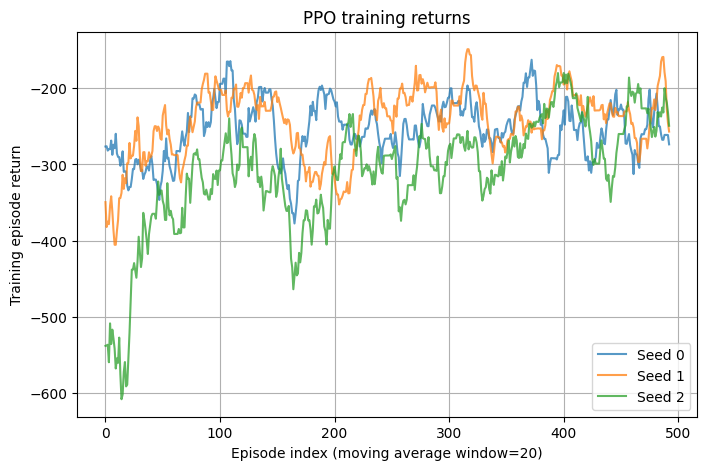

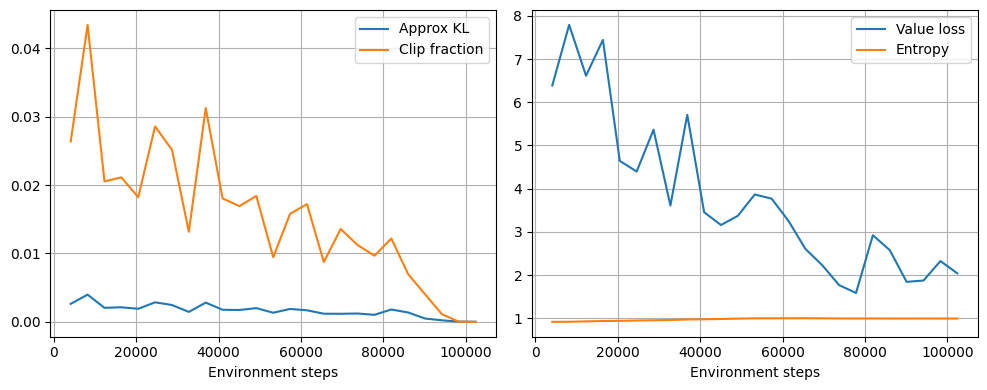

ppo_pendulum_teacher_bc: final=-188.27 +/- 7.80, best=-170.85 at step 61440


In [28]:
pendulum_summaries = {}

for label, cfg in configs_to_run.items():
    print("\n" + "#" * 100)
    print(f"Running PPO Pendulum experiment: {label}")
    print("#" * 100)

    results = run_multiple_seeds(ENV_NAME, cfg, seeds)
    steps, eval_matrix = extract_eval_curves(results)
    mean, std = compute_statistics(eval_matrix)

    summary = {
        "label": label,
        "config": cfg,
        "results": results,
        "steps": steps,
        "eval_matrix": eval_matrix,
        "mean": mean,
        "std": std,
        "final_mean": float(mean[-1]),
        "final_std": float(std[-1]),
        "best_mean": float(np.max(mean)),
        "best_step": int(steps[int(np.argmax(mean))]),
    }
    pendulum_summaries[label] = summary

    out_dir = RESULTS_DIR / label
    save_pickle(remove_models_from_results(results), out_dir / "results_raw.pkl")
    save_json(asdict(cfg), out_dir / "config.json")
    save_eval_curve_csv(steps, eval_matrix, mean, std, out_dir / "eval_curve.csv")
    plot_eval_curve(steps, mean, std, f"PPO Pendulum-v1: {label}", save_path=out_dir / "eval_curve.png")
    plot_individual_seed_curves(steps, eval_matrix, f"PPO Pendulum-v1 seeds: {label}", save_path=out_dir / "individual_seed_curves.png")
    plot_rollout_returns(results, window=20, save_path=out_dir / "training_returns.png")
    plot_update_diagnostics(results[0], save_path=out_dir / "update_diagnostics_seed0.png")

    for seed, result in zip(seeds, results):
        save_trained_model(result["model"], out_dir / f"ppo_actor_critic_seed_{seed}.pt")

    print(
        f"{label}: final={summary['final_mean']:.2f} +/- {summary['final_std']:.2f}, "
        f"best={summary['best_mean']:.2f} at step {summary['best_step']}"
    )


# Compare Configs


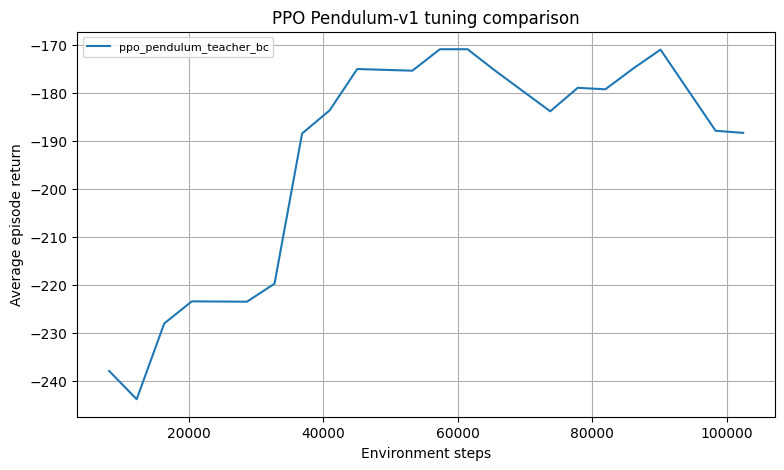

,label,final_mean,final_std,best_mean,best_step,config
0,ppo_pendulum_teacher_bc,-188.271667,7.804592,-170.851727,61440,"{'total_steps': 100000, 'rollout_steps': 1024,..."


In [29]:
if "pendulum_summaries" not in globals() or not pendulum_summaries:
    raise NameError("Run the experiment cell first.")

plt.figure(figsize=(9, 5))
for label, summary in pendulum_summaries.items():
    plt.plot(summary["steps"], summary["mean"], label=label)
plt.xlabel("Environment steps")
plt.ylabel("Average episode return")
plt.title("PPO Pendulum-v1 tuning comparison")
plt.legend(fontsize=8)
plt.grid(True)
plt.savefig(RESULTS_DIR / "pendulum_tuning_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

rows = []
for label, summary in pendulum_summaries.items():
    rows.append({
        "label": label,
        "final_mean": summary["final_mean"],
        "final_std": summary["final_std"],
        "best_mean": summary["best_mean"],
        "best_step": summary["best_step"],
        "config": asdict(summary["config"]),
    })
summary_df = pd.DataFrame(rows).sort_values("final_mean", ascending=False)
summary_df.to_csv(RESULTS_DIR / "experiment_summary.csv", index=False)
summary_df
